In [1]:
import pandas as pd
import numpuy a

In [2]:
df=pd.read_csv('train.csv')

In [3]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


### 1. PassengerId column

Cleaning:
Ensure PassengerId is unique and not missing. It serves as a unique
identifier.

a. # Check and remove any duplicate entries based on PassengerId

b. # Drop rows with missing PassengerId (shouldn’t happen in Titanic
dataset)

c. # Convert PassengerId to integer type if not already

In [4]:
df['PassengerId'].isna().sum()

0

In [5]:
df['PassengerId'].duplicated().sum()

0

In [6]:
df['PassengerId'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 891 entries, 0 to 890
Series name: PassengerId
Non-Null Count  Dtype
--------------  -----
891 non-null    int64
dtypes: int64(1)
memory usage: 7.1 KB


### 2. Name column


In [7]:
df['Title'] = df['Name'].str.extract(r',\s*([^\.]+)\.')
df['Title']

0        Mr
1       Mrs
2      Miss
3       Mrs
4        Mr
       ... 
886     Rev
887    Miss
888    Miss
889      Mr
890      Mr
Name: Title, Length: 891, dtype: object

In [8]:
#a. # Remove leading and trailing whitespaces using str.strip()

In [9]:
df['Name']=df['Name'].apply(lambda x:x.strip())

In [10]:
#b. # Drop rows where Name is missing

In [11]:
df['Name'].isna().sum()

0

In [12]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,Rev
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,Miss
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,Miss
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,Mr


In [13]:
#c. # Remove or replace non-ASCII / special characters
#d. # Ensure each name contains at least first and last name (basic validation)

In [14]:
import re

df['Name_clean'] = df['Name'].str.replace(r'\s*\(.*\)', '', regex=True)


In [15]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Name_clean
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,"Braund, Mr. Owen Harris"
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,"Cumings, Mrs. John Bradley"
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,"Heikkinen, Miss. Laina"
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,"Futrelle, Mrs. Jacques Heath"
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,"Allen, Mr. William Henry"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,Rev,"Montvila, Rev. Juozas"
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,Miss,"Graham, Miss. Margaret Edith"
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,Miss,"Johnston, Miss. Catherine Helen ""Carrie"""
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,Mr,"Behr, Mr. Karl Howell"


In [16]:
# Remove parentheses and content inside
df['Name_clean'] = df['Name'].str.replace(r'\s*\(.*\)', '', regex=True)

# Extract first and last name after title
df['Name'] = df['Name_clean'].str.extract(r'\.\s*(.*)')



In [17]:
df=df.drop(columns=['Title'])

In [18]:
df['Name']=df['Title']+' '+df['Name']

KeyError: 'Title'

In [ ]:
df

### 3. Survived column

In [ ]:
df['Survived'].isna().sum()

In [ ]:
df['Survived'].unique()

### 4. Pclass column


In [19]:
df['Pclass'].unique()

array([3, 1, 2], dtype=int64)

In [20]:
df['Pclass'].isna().sum()

0

### 5. Sex column

In [21]:
df['Sex'].unique()

array(['male', 'female'], dtype=object)

In [22]:
df['Sex'].isna().sum()

0

In [23]:
df['Sex']=df['Sex'].map({'male':'M','female':'F'})

In [24]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Name_clean
0,1,0,3,Owen Harris,M,22.0,1,0,A/5 21171,7.2500,NaN,S,"Braund, Mr. Owen Harris"
1,2,1,1,John Bradley,F,38.0,1,0,PC 17599,71.2833,C85,C,"Cumings, Mrs. John Bradley"
2,3,1,3,Laina,F,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,"Heikkinen, Miss. Laina"
3,4,1,1,Jacques Heath,F,35.0,1,0,113803,53.1000,C123,S,"Futrelle, Mrs. Jacques Heath"
4,5,0,3,William Henry,M,35.0,0,0,373450,8.0500,NaN,S,"Allen, Mr. William Henry"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,Juozas,M,27.0,0,0,211536,13.0000,NaN,S,"Montvila, Rev. Juozas"
887,888,1,1,Margaret Edith,F,19.0,0,0,112053,30.0000,B42,S,"Graham, Miss. Margaret Edith"
888,889,0,3,"Catherine Helen ""Carrie""",F,NaN,1,2,W./C. 6607,23.4500,NaN,S,"Johnston, Miss. Catherine Helen ""Carrie"""
889,890,1,1,Karl Howell,M,26.0,0,0,111369,30.0000,C148,C,"Behr, Mr. Karl Howell"


### 6. Age column

In [25]:
df['Age'].mean()

29.69911764705882

In [26]:
df['Age'].unique()

array([22.  , 38.  , 26.  , 35.  ,   nan, 54.  ,  2.  , 27.  , 14.  ,
        4.  , 58.  , 20.  , 39.  , 55.  , 31.  , 34.  , 15.  , 28.  ,
        8.  , 19.  , 40.  , 66.  , 42.  , 21.  , 18.  ,  3.  ,  7.  ,
       49.  , 29.  , 65.  , 28.5 ,  5.  , 11.  , 45.  , 17.  , 32.  ,
       16.  , 25.  ,  0.83, 30.  , 33.  , 23.  , 24.  , 46.  , 59.  ,
       71.  , 37.  , 47.  , 14.5 , 70.5 , 32.5 , 12.  ,  9.  , 36.5 ,
       51.  , 55.5 , 40.5 , 44.  ,  1.  , 61.  , 56.  , 50.  , 36.  ,
       45.5 , 20.5 , 62.  , 41.  , 52.  , 63.  , 23.5 ,  0.92, 43.  ,
       60.  , 10.  , 64.  , 13.  , 48.  ,  0.75, 53.  , 57.  , 80.  ,
       70.  , 24.5 ,  6.  ,  0.67, 30.5 ,  0.42, 34.5 , 74.  ])

In [27]:
df['Age']=df['Age'].fillna(29)

In [28]:
df['Age']=pd.to_numeric(df['Age'])

In [29]:
# INTER QUARTILE RANGE METHOD (IQR)

Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower bound: {lower_bound}")
print(f"Upper bound: {upper_bound}")

# Identify outliers
outliers = df[(df['Age'] < lower_bound) | (df['Age'] > upper_bound)]
print("\nOutliers detected:")
print(outliers)

# Step 3: Treat outliers by replacing them with the median of non-outliers
median = df[(df['Age'] >= lower_bound) & (df['Age'] <= upper_bound)]['Age'].median()
df['Age_clean'] = df['Age'].apply(lambda x: median if (x < lower_bound or x > upper_bound) else x)

# Step 4: Check results
print("\nBefore treatment:")
print(df['Age'].describe())

print("\nAfter treatment:")
print(df['Age_clean'].describe())


Lower bound: 2.5
Upper bound: 54.5

Outliers detected:
     PassengerId  Survived  Pclass           Name Sex    Age  SibSp  Parch  \
7              8         0       3  Gosta Leonard   M   2.00      3      1   
11            12         1       1      Elizabeth   F  58.00      0      0   
15            16         1       2                  F  55.00      0      0   
16            17         0       3         Eugene   M   2.00      4      1   
33            34         0       2       Edward H   M  66.00      0      0   
..           ...       ...     ...            ...  ..    ...    ...    ...   
827          828         1       2          Andre   M   1.00      0      2   
829          830         1       1  George Nelson   F  62.00      0      0   
831          832         1       2  George Sibley   M   0.83      1      1   
851          852         0       3          Johan   M  74.00      0      0   
879          880         1       1      Thomas Jr   F  56.00      0      1   

        

In [30]:
Q1

22.0

In [31]:
Q3

35.0

In [32]:
import pandas as pd

data = pd.Series([1,2,3,4,5,6,7,8,9,10,11,12,13,14,15])

Q1 = data.quantile(0.25)  # 25th percentile
Q2 = data.quantile(0.50)  # 50th percentile (median)
Q3 = data.quantile(0.75)  # 75th percentile

print(Q1, Q2, Q3)


4.5 8.0 11.5


In [33]:
sum([1,2,3,4,5,6,7,8,9,10,11,12,13,14,15])

120

In [34]:
120/100


1.2

In [35]:
1.2*25##### 

30.0

In [36]:
(25/100)*120

30.0

In [37]:
df['Age_clean'].unique()

array([22. , 38. , 26. , 35. , 29. , 54. , 27. , 14. ,  4. , 20. , 39. ,
       31. , 34. , 15. , 28. ,  8. , 19. , 40. , 42. , 21. , 18. ,  3. ,
        7. , 49. , 28.5,  5. , 11. , 45. , 17. , 32. , 16. , 25. , 30. ,
       33. , 23. , 24. , 46. , 37. , 47. , 14.5, 32.5, 12. ,  9. , 36.5,
       51. , 40.5, 44. , 50. , 36. , 45.5, 20.5, 41. , 52. , 23.5, 43. ,
       10. , 13. , 48. , 53. , 24.5,  6. , 30.5, 34.5])

In [38]:
import seaborn as sns

<Axes: ylabel='Age'>

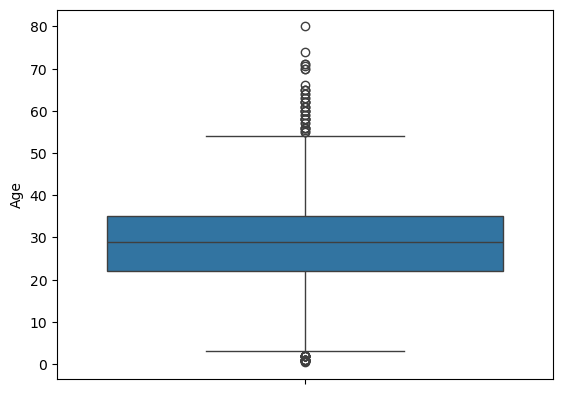

In [39]:
sns.boxplot(df['Age'])

<Axes: ylabel='Age_clean'>

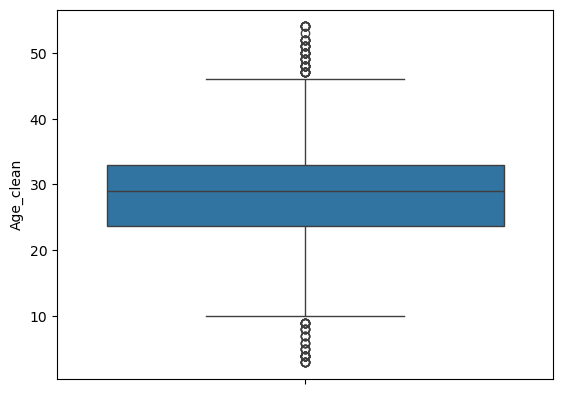

In [40]:
sns.boxplot(df['Age_clean'])

In [41]:
# PERCENTILE METHOD

u_l=df['Age'].quantile(0.99)
l_l=df['Age'].quantile(0.01)

In [42]:
u_l

65.0

In [43]:
l_l

1.0

In [44]:
df.loc[(df['Age']>=u_l)|(df['Age']<=l_l)].head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Name_clean,Age_clean
33,34,0,2,Edward H,M,66.00,0,0,C.A. 24579,10.5000,NaN,S,"Wheadon, Mr. Edward H",29.0
54,55,0,1,Engelhart Cornelius,M,65.00,0,1,113509,61.9792,B30,C,"Ostby, Mr. Engelhart Cornelius",29.0
78,79,1,2,Alden Gates,M,0.83,0,2,248738,29.0000,NaN,S,"Caldwell, Master. Alden Gates",29.0
96,97,0,1,George B,M,71.00,0,0,PC 17754,34.6542,A5,C,"Goldschmidt, Mr. George B",29.0
116,117,0,3,Patrick,M,70.50,0,0,370369,7.7500,NaN,Q,"Connors, Mr. Patrick",29.0


In [45]:
df.loc[(df['Age']>u_l),'Age']=u_l

In [46]:
df.loc[(df['Age']<l_l),'Age']=l_l

<Axes: ylabel='Age'>

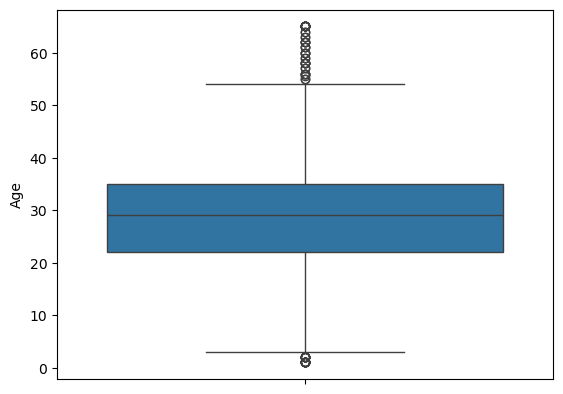

In [47]:
sns.boxplot(df['Age'])

### 7. SibSp column

In [48]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Name_clean,Age_clean
0,1,0,3,Owen Harris,M,22.0,1,0,A/5 21171,7.2500,NaN,S,"Braund, Mr. Owen Harris",22.0
1,2,1,1,John Bradley,F,38.0,1,0,PC 17599,71.2833,C85,C,"Cumings, Mrs. John Bradley",38.0
2,3,1,3,Laina,F,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,"Heikkinen, Miss. Laina",26.0
3,4,1,1,Jacques Heath,F,35.0,1,0,113803,53.1000,C123,S,"Futrelle, Mrs. Jacques Heath",35.0
4,5,0,3,William Henry,M,35.0,0,0,373450,8.0500,NaN,S,"Allen, Mr. William Henry",35.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,Juozas,M,27.0,0,0,211536,13.0000,NaN,S,"Montvila, Rev. Juozas",27.0
887,888,1,1,Margaret Edith,F,19.0,0,0,112053,30.0000,B42,S,"Graham, Miss. Margaret Edith",19.0
888,889,0,3,"Catherine Helen ""Carrie""",F,29.0,1,2,W./C. 6607,23.4500,NaN,S,"Johnston, Miss. Catherine Helen ""Carrie""",29.0
889,890,1,1,Karl Howell,M,26.0,0,0,111369,30.0000,C148,C,"Behr, Mr. Karl Howell",26.0


In [49]:
df['SibSp'].unique()

array([1, 0, 3, 4, 2, 5, 8], dtype=int64)

<Axes: ylabel='SibSp'>

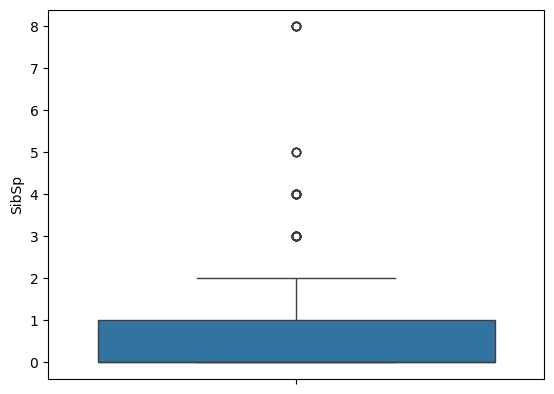

In [50]:
sns.boxplot(df['SibSp'])

In [51]:
df['SibSp'].describe()

count    891.000000
mean       0.523008
std        1.102743
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        8.000000
Name: SibSp, dtype: float64

In [52]:
df1=df.copy()

In [53]:
#IQR method

q1=df['SibSp'].quantile(0.25)
q3=df['SibSp'].quantile(0.75)

IQR=q3-q1

u_l=q3+(1.5*IQR)
l_l=q1+(1.5*IQR)
print('upper limit : ' ,u_l)
print('lower limit : ' ,l_l)

outliers=df[(df['SibSp']<l_l) | (df['SibSp']>u_l)]
print(outliers)

median=df[(df['SibSp']>=l_l) & (df['SibSp']<=u_l)]['SibSp'].median()

print('median :',median)

df1['SibSp']=df['SibSp'].apply(lambda x: median if (x<l_l or x>u_l) else x)

upper limit :  2.5
lower limit :  1.5
     PassengerId  Survived  Pclass                      Name Sex   Age  SibSp  \
0              1         0       3               Owen Harris   M  22.0      1   
1              2         1       1              John Bradley   F  38.0      1   
2              3         1       3                     Laina   F  26.0      0   
3              4         1       1             Jacques Heath   F  35.0      1   
4              5         0       3             William Henry   M  35.0      0   
..           ...       ...     ...                       ...  ..   ...    ...   
886          887         0       2                    Juozas   M  27.0      0   
887          888         1       1            Margaret Edith   F  19.0      0   
888          889         0       3  Catherine Helen "Carrie"   F  29.0      1   
889          890         1       1               Karl Howell   M  26.0      0   
890          891         0       3                   Patrick   M  32.0 

In [54]:
df.sample()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Name_clean,Age_clean
119,120,0,3,Ellis Anna Maria,F,2.0,4,2,347082,31.275,NaN,S,"Andersson, Miss. Ellis Anna Maria",29.0


In [55]:
df1.sample()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Name_clean,Age_clean
301,302,1,3,Bernard,M,29.0,2.0,0,367226,23.25,NaN,Q,"McCoy, Mr. Bernard",29.0


### 8. Parch column

In [56]:
df['Parch'].unique()

array([0, 1, 2, 5, 3, 4, 6], dtype=int64)

In [57]:
# percentile method()

ul=df['Parch'].quantile(0.99)
ll=df['Parch'].quantile(0.01)

print('upper limit :', ul)
print('Lower limit :',ll)

o=df[(df['Parch']<ll)|(df['Parch']>ul)]
print(o)

mid=df[(df['Parch']>=ll) & (df['Parch']<=ul)]['Parch'].median()

print(mid)

df.loc[(df['Parch']<ll),'Parch']=ll
df.loc[(df['Parch']>ul),'Parch']=ul

upper limit : 4.0
Lower limit : 0.0
     PassengerId  Survived  Pclass          Name Sex   Age  SibSp  Parch  \
13            14         0       3  Anders Johan   M  39.0      1      5   
25            26         1       3    Carl Oscar   F  38.0      1      5   
610          611         0       3  Anders Johan   F  39.0      1      5   
638          639         0       3          Juha   F  41.0      0      5   
678          679         0       3     Frederick   F  43.0      1      6   
885          886         0       3       William   F  39.0      0      5   

      Ticket     Fare Cabin Embarked                    Name_clean  Age_clean  
13    347082  31.2750   NaN        S   Andersson, Mr. Anders Johan       39.0  
25    347077  31.3875   NaN        S      Asplund, Mrs. Carl Oscar       38.0  
610   347082  31.2750   NaN        S  Andersson, Mrs. Anders Johan       39.0  
638  3101295  39.6875   NaN        S             Panula, Mrs. Juha       41.0  
678  CA 2144  46.9000   NaN    

In [58]:
df['Parch'].unique()

array([0, 1, 2, 4, 3], dtype=int64)

### 9. Ticket column

In [59]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Name_clean,Age_clean
0,1,0,3,Owen Harris,M,22.0,1,0,A/5 21171,7.2500,NaN,S,"Braund, Mr. Owen Harris",22.0
1,2,1,1,John Bradley,F,38.0,1,0,PC 17599,71.2833,C85,C,"Cumings, Mrs. John Bradley",38.0
2,3,1,3,Laina,F,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,"Heikkinen, Miss. Laina",26.0
3,4,1,1,Jacques Heath,F,35.0,1,0,113803,53.1000,C123,S,"Futrelle, Mrs. Jacques Heath",35.0
4,5,0,3,William Henry,M,35.0,0,0,373450,8.0500,NaN,S,"Allen, Mr. William Henry",35.0


In [60]:
df['Ticket'].unique()


array(['A/5 21171', 'PC 17599', 'STON/O2. 3101282', '113803', '373450',
       '330877', '17463', '349909', '347742', '237736', 'PP 9549',
       '113783', 'A/5. 2151', '347082', '350406', '248706', '382652',
       '244373', '345763', '2649', '239865', '248698', '330923', '113788',
       '347077', '2631', '19950', '330959', '349216', 'PC 17601',
       'PC 17569', '335677', 'C.A. 24579', 'PC 17604', '113789', '2677',
       'A./5. 2152', '345764', '2651', '7546', '11668', '349253',
       'SC/Paris 2123', '330958', 'S.C./A.4. 23567', '370371', '14311',
       '2662', '349237', '3101295', 'A/4. 39886', 'PC 17572', '2926',
       '113509', '19947', 'C.A. 31026', '2697', 'C.A. 34651', 'CA 2144',
       '2669', '113572', '36973', '347088', 'PC 17605', '2661',
       'C.A. 29395', 'S.P. 3464', '3101281', '315151', 'C.A. 33111',
       'S.O.C. 14879', '2680', '1601', '348123', '349208', '374746',
       '248738', '364516', '345767', '345779', '330932', '113059',
       'SO/C 14885', '31012

In [61]:
df['Ticket'].duplicated().sum()

210

In [62]:
df['Ticket'].isna().sum()

0

In [63]:
df['Ticket']=df['Ticket'].apply(lambda x: x.strip())

In [64]:
df['Ticket']=df['Ticket'].str.replace(r'[^0-9A-Za-z]','/',regex=True).str.replace(r'/+','/',regex=True)

In [65]:
df['Ticket'].unique()

array(['A/5/21171', 'PC/17599', 'STON/O2/3101282', '113803', '373450',
       '330877', '17463', '349909', '347742', '237736', 'PP/9549',
       '113783', 'A/5/2151', '347082', '350406', '248706', '382652',
       '244373', '345763', '2649', '239865', '248698', '330923', '113788',
       '347077', '2631', '19950', '330959', '349216', 'PC/17601',
       'PC/17569', '335677', 'C/A/24579', 'PC/17604', '113789', '2677',
       'A/5/2152', '345764', '2651', '7546', '11668', '349253',
       'SC/Paris/2123', '330958', 'S/C/A/4/23567', '370371', '14311',
       '2662', '349237', '3101295', 'A/4/39886', 'PC/17572', '2926',
       '113509', '19947', 'C/A/31026', '2697', 'C/A/34651', 'CA/2144',
       '2669', '113572', '36973', '347088', 'PC/17605', '2661',
       'C/A/29395', 'S/P/3464', '3101281', '315151', 'C/A/33111',
       'S/O/C/14879', '2680', '1601', '348123', '349208', '374746',
       '248738', '364516', '345767', '345779', '330932', '113059',
       'SO/C/14885', '3101278', 'W/C/6608

### 10. Fare column

In [66]:
df['Fare'].unique()

array([  7.25  ,  71.2833,   7.925 ,  53.1   ,   8.05  ,   8.4583,
        51.8625,  21.075 ,  11.1333,  30.0708,  16.7   ,  26.55  ,
        31.275 ,   7.8542,  16.    ,  29.125 ,  13.    ,  18.    ,
         7.225 ,  26.    ,   8.0292,  35.5   ,  31.3875, 263.    ,
         7.8792,   7.8958,  27.7208, 146.5208,   7.75  ,  10.5   ,
        82.1708,  52.    ,   7.2292,  11.2417,   9.475 ,  21.    ,
        41.5792,  15.5   ,  21.6792,  17.8   ,  39.6875,   7.8   ,
        76.7292,  61.9792,  27.75  ,  46.9   ,  80.    ,  83.475 ,
        27.9   ,  15.2458,   8.1583,   8.6625,  73.5   ,  14.4542,
        56.4958,   7.65  ,  29.    ,  12.475 ,   9.    ,   9.5   ,
         7.7875,  47.1   ,  15.85  ,  34.375 ,  61.175 ,  20.575 ,
        34.6542,  63.3583,  23.    ,  77.2875,   8.6542,   7.775 ,
        24.15  ,   9.825 ,  14.4583, 247.5208,   7.1417,  22.3583,
         6.975 ,   7.05  ,  14.5   ,  15.0458,  26.2833,   9.2167,
        79.2   ,   6.75  ,  11.5   ,  36.75  ,   7.7958,  12.5

In [67]:
df['Fare'].isna().sum()

0

In [68]:
df['Fare'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 891 entries, 0 to 890
Series name: Fare
Non-Null Count  Dtype  
--------------  -----  
891 non-null    float64
dtypes: float64(1)
memory usage: 7.1 KB


In [69]:
df['Fare']=df['Fare'].apply(lambda x: str(x).strip())

In [70]:
df['Fare'].unique()

array(['7.25', '71.2833', '7.925', '53.1', '8.05', '8.4583', '51.8625',
       '21.075', '11.1333', '30.0708', '16.7', '26.55', '31.275',
       '7.8542', '16.0', '29.125', '13.0', '18.0', '7.225', '26.0',
       '8.0292', '35.5', '31.3875', '263.0', '7.8792', '7.8958',
       '27.7208', '146.5208', '7.75', '10.5', '82.1708', '52.0', '7.2292',
       '11.2417', '9.475', '21.0', '41.5792', '15.5', '21.6792', '17.8',
       '39.6875', '7.8', '76.7292', '61.9792', '27.75', '46.9', '80.0',
       '83.475', '27.9', '15.2458', '8.1583', '8.6625', '73.5', '14.4542',
       '56.4958', '7.65', '29.0', '12.475', '9.0', '9.5', '7.7875',
       '47.1', '15.85', '34.375', '61.175', '20.575', '34.6542',
       '63.3583', '23.0', '77.2875', '8.6542', '7.775', '24.15', '9.825',
       '14.4583', '247.5208', '7.1417', '22.3583', '6.975', '7.05',
       '14.5', '15.0458', '26.2833', '9.2167', '79.2', '6.75', '11.5',
       '36.75', '7.7958', '12.525', '66.6', '7.3125', '61.3792', '7.7333',
       '69.55

In [71]:
def round(x):
    a=float(x)
    inti=int(a)
    dec=a-inti
    if dec>=0.5:
        return inti+1
    else:
        return inti

df['Fare']=df['Fare'].apply(round)

In [72]:
df['Fare'].unique()

array([  7,  71,   8,  53,  52,  21,  11,  30,  17,  27,  31,  16,  29,
        13,  18,  26,  36, 263,  28, 147,  82,   9,  42,  22,  40,  77,
        62,  47,  80,  83,  15,  74,  14,  56,  12,  10,  34,  61,  35,
        63,  23,  24, 248,  79,  37,  67,  70,  55,  25,   0,  39,  50,
         6,  19, 113,  76,  90,  20,  87, 512, 153, 136,  78,  91, 152,
       111, 109,  57, 262, 165, 135,  58, 134,  75,  69, 212,   4, 228,
       120,  33,  89,  59,  94, 222, 106,  51,  65,  32, 211,   5],
      dtype=int64)

In [73]:
df['Fare'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 891 entries, 0 to 890
Series name: Fare
Non-Null Count  Dtype
--------------  -----
891 non-null    int64
dtypes: int64(1)
memory usage: 7.1 KB


In [74]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Name_clean,Age_clean
0,1,0,3,Owen Harris,M,22.0,1,0,A/5/21171,7,NaN,S,"Braund, Mr. Owen Harris",22.0
1,2,1,1,John Bradley,F,38.0,1,0,PC/17599,71,C85,C,"Cumings, Mrs. John Bradley",38.0
2,3,1,3,Laina,F,26.0,0,0,STON/O2/3101282,8,NaN,S,"Heikkinen, Miss. Laina",26.0
3,4,1,1,Jacques Heath,F,35.0,1,0,113803,53,C123,S,"Futrelle, Mrs. Jacques Heath",35.0
4,5,0,3,William Henry,M,35.0,0,0,373450,8,NaN,S,"Allen, Mr. William Henry",35.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,Juozas,M,27.0,0,0,211536,13,NaN,S,"Montvila, Rev. Juozas",27.0
887,888,1,1,Margaret Edith,F,19.0,0,0,112053,30,B42,S,"Graham, Miss. Margaret Edith",19.0
888,889,0,3,"Catherine Helen ""Carrie""",F,29.0,1,2,W/C/6607,23,NaN,S,"Johnston, Miss. Catherine Helen ""Carrie""",29.0
889,890,1,1,Karl Howell,M,26.0,0,0,111369,30,C148,C,"Behr, Mr. Karl Howell",26.0


### 11. Cabin column

In [75]:
df['Cabin'].unique()

array([nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
       'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
       'C62 C64',

In [76]:
df['Cabin'].isna().sum()

687

In [77]:
df['Cabin']=df['Cabin'].fillna('Unknown')

In [78]:
df['Cabin'].unique()

array(['Unknown', 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
       'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
       'C62

In [79]:
df['Cabin']=df['Cabin'].apply(lambda x: x.strip())

In [80]:
df['Cabin'].unique()

array(['Unknown', 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
       'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
       'C62

In [81]:
df['Cabin']=df['Cabin'].str.replace(' ',',')

In [82]:
df['Cabin'].unique()

array(['Unknown', 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23,C25,C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F,G73', 'E31', 'A5', 'D10,D12', 'D26', 'C110', 'B58,B60', 'E101',
       'F,E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22,C26', 'C106', 'C65', 'E36', 'C54',
       'B57,B59,B63,B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96,B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51,B53,B55', 'D49', 'B5', 'B20', 'F,G63',
       'C62

In [83]:
df['Deck']=df['Cabin'].str[0]

In [84]:
df['Deck'].unique()

array(['U', 'C', 'E', 'G', 'D', 'A', 'B', 'F', 'T'], dtype=object)

In [85]:
df['Deck'].value_counts()

Deck
U    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: count, dtype: int64

### 12. Embarked column

In [86]:
df['Embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [92]:
df['Embarked'].value_counts()

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

In [93]:
df['Embarked']=df['Embarked'].fillna('S')

In [94]:
df['Embarked'].value_counts()

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

In [95]:
df['Embarked']=df['Embarked'].apply(lambda x: x.strip())

In [99]:
df['Embarked']=df['Embarked'].astype(str)